#  Previsão de Direção de Ações com LSTM

Neste trabalho, o objetivo é prever se o preço da ação da Petrobras (PETR4) irá subir ou cair no próximo dia.

Para enriquecer o modelo, também foi utilizada a ação da Vale (VALE3), considerando que diferentes ativos do mercado podem apresentar relações entre si.

A abordagem utilizada foi a de classificação binária:
- 1 → preço sobe
- 0 → preço cai

Nesta etapa, são importadas as bibliotecas necessárias para manipulação de dados, coleta de dados financeiros e construção do modelo de deep learning.

In [18]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn

#Os dados foram coletados utilizando a biblioteca yfinance.

## Foram utilizados dois ativos:
- PETR4 (Petrobras)
- VALE3 (Vale)

Os dados foram combinados com base na data para permitir que o modelo utilize informações de ambos os ativos.

In [19]:
# Baixando dados da Petrobras
df_petr = yf.download('PETR4.SA', start='2018-01-01', end='2024-01-01')

# Baixando dados da Vale
df_vale = yf.download('VALE3.SA', start='2018-01-01', end='2024-01-01')

# Selecionando colunas da Petrobras
df_petr = df_petr[['Open', 'High', 'Low', 'Close', 'Volume']]

# Selecionando apenas o fechamento da Vale
df_vale = df_vale[['Close']]

# Renomeando para evitar conflito
df_vale.rename(columns={'Close': 'Vale_Close'}, inplace=True)

# Juntando os dados
df = df_petr.join(df_vale, how='inner')

# Removendo valores nulos
df.dropna(inplace=True)

df.head()

/tmp/ipykernel_35149/3295974966.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_petr = yf.download('PETR4.SA', start='2018-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_35149/3295974966.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_vale = yf.download('VALE3.SA', start='2018-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Open,High,Low,Close,Volume,Vale_Close
Ticker,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA,VALE3.SA
Date,,,,,,
2018-01-02,4.313444,4.409358,4.313444,4.409358,33461800,21.669313
2018-01-03,4.393372,4.454650,4.361402,4.449322,55940900,21.539465
2018-01-04,4.470637,4.518593,4.428009,4.457315,37064900,21.627758
2018-01-05,4.449322,4.491950,4.414686,4.483957,26958200,21.965372
2018-01-08,4.459979,4.537243,4.451986,4.537243,28400000,22.453602


## O gráfico abaixo mostra o comportamento das duas ações ao longo do tempo, permitindo observar possíveis padrões ou semelhanças.

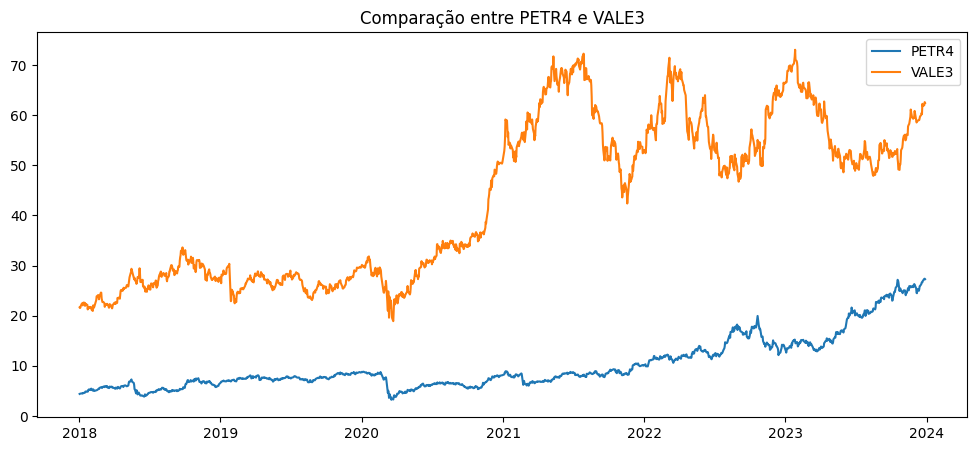

In [20]:
plt.figure(figsize=(12,5))
plt.plot(df['Close'], label='PETR4')
plt.plot(df['Vale_Close'], label='VALE3')
plt.legend()
plt.title('Comparação entre PETR4 e VALE3')
plt.show()

# A variável alvo foi criada comparando o preço de fechamento com o dia seguinte.

## Se o preço subir, recebe valor 1, caso contrário recebe 0.

In [21]:
# Criando variável alvo
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

df.dropna(inplace=True)

df[['Close', 'Target']].head()

Price,Close,Target
Ticker,PETR4.SA,
Date,,
2018-01-02,4.409358,1
2018-01-03,4.449322,1
2018-01-04,4.457315,1
2018-01-05,4.483957,1
2018-01-08,4.537243,0


## Essa visualização mostra quantos dias o preço subiu ou caiu.

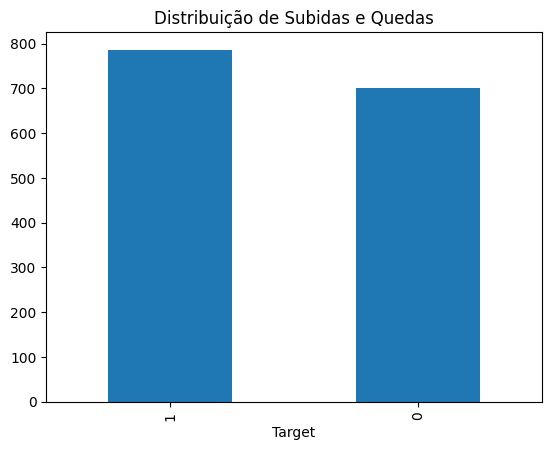

In [22]:
df['Target'].value_counts().plot(kind='bar')
plt.title('Distribuição de Subidas e Quedas')
plt.show()

## A normalização foi aplicada para colocar todas as variáveis na mesma escala, o que melhora o desempenho do modelo.

In [23]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    df[['Open', 'High', 'Low', 'Close', 'Volume', 'Vale_Close']]
)

## Os dados foram transformados em sequências de 20 dias, pois a LSTM trabalha com dados temporais e utiliza informações do passado para prever o futuro.

In [24]:
def create_sequences(data, target, seq_length):
    X, y = [], []

    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(target[i+seq_length])

    return np.array(X), np.array(y)

seq_length = 20

X, y = create_sequences(scaled_data, df['Target'].values, seq_length)

print(X.shape, y.shape)

(1467, 20, 6) (1467,)


## Os dados foram divididos em treino e teste para avaliar o modelo em dados que ele não viu durante o treinamento.

In [25]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

## Os dados foram convertidos para tensores, pois o PyTorch trabalha com esse tipo de estrutura.

In [26]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

## A rede LSTM foi utilizada para capturar padrões ao longo do tempo.

A função sigmoid foi aplicada na saída para gerar valores entre 0 e 1, representando a probabilidade de subida.

In [27]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        out = self.sigmoid(out)
        return out

input_size = X.shape[2]
hidden_size = 50
num_layers = 2

model = LSTMModel(input_size, hidden_size, num_layers)

## A função de perda utilizada foi BCELoss, adequada para classificação binária.

O otimizador Adam foi escolhido por ser eficiente no treinamento de redes neurais.

In [28]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## Durante o treinamento, o modelo ajusta seus pesos com base no erro utilizando o processo de backpropagation.

In [29]:
epochs = 10

for epoch in range(epochs):
    model.train()

    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f'Época {epoch+1}, Loss: {loss.item():.4f}')

Época 1, Loss: 0.6981
Época 2, Loss: 0.6972
Época 3, Loss: 0.6963
Época 4, Loss: 0.6955
Época 5, Loss: 0.6948
Época 6, Loss: 0.6942
Época 7, Loss: 0.6937
Época 8, Loss: 0.6932
Época 9, Loss: 0.6929
Época 10, Loss: 0.6926


## A avaliação foi realizada utilizando a acurácia, que mede a proporção de previsões corretas do modelo.

In [30]:
model.eval()

with torch.no_grad():
    predictions = model(X_test_t)
    predictions = (predictions > 0.5).float()

    accuracy = (predictions == y_test_t).float().mean()

print(f'Acurácia: {accuracy.item():.4f}')

Acurácia: 0.5612


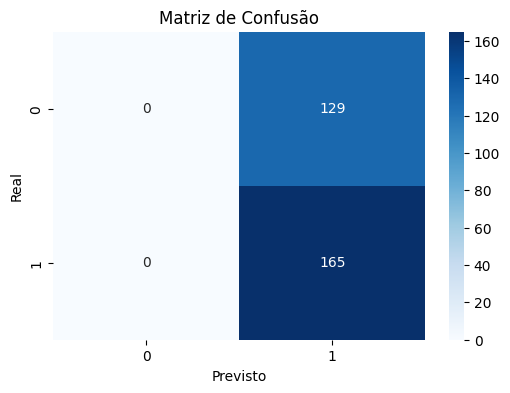

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test_t.numpy(), predictions.numpy())

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

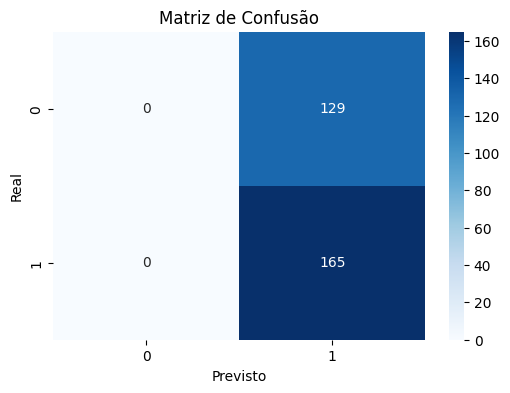

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test_t.numpy(), predictions.numpy())

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

Neste trabalho, foi utilizada uma rede LSTM para prever a direção do preço da ação da Petrobras.

A inclusão da ação da Vale buscou enriquecer o modelo com informações adicionais do mercado.

Os resultados mostram que o modelo consegue capturar alguns padrões, mas ainda apresenta limitações, especialmente devido à complexidade do mercado financeiro.

In [34]:
df['Target'].value_counts()

,count
Target,
1,786
0,701
